# Description
Non-dimensionalize and collapse all SWE data on a single curve.

# Load analysis functions

In [2]:
%run ...../imports.ipynb
%run ...../analysisScripts/snotelAnalysisFunctions.ipynb

# Load data

add choice for loading all stations or just biased corrected stations...

In [3]:
stationBiasDict = loadTempBiasMarker()

In [4]:
rootPath = '...../snotelData/raw/'
stateNames = ['CO','AK','AZ','CA','ID','MT','NM','NV','OR','SD','UT','WA','WY']
metaData = loadStationMetaData()

In [5]:
allStateDict = {}
for stateName in tqdm(stateNames):
    stateFileNames = glob.glob(rootPath + stateName + '/' + '*')
    stateDataAll = [csvToXarray(f) for f in stateFileNames]
    stateDataCleaned = [s for s in stateDataAll if s.BAD_DATA==False]
    allStateDict[stateName] = stateDataCleaned

100%|███████████████████████████████████████████| 13/13 [00:25<00:00,  1.98s/it]


In [6]:
## Filter stations with the same functions used in other notebooks ##
allStateDict_filtered = filterStations(stateNames,allStateDict)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

In [7]:
## Calculate frozen season length and Pw
allStateDict_prcpRate_tauF = winterPrcpRateByYear(stateNames,allStateDict_filtered,accumThresh = 0)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM']: 3/27         

/tmp/ipykernel_142114/132286664.py:58: RuntimeWarning: invalid value encountered in scalar divide
  P_duringSnow = np.sum(currPInterp[firstSnowInd:indMax])/tMax_tStart_days


['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

# Calculate climatological SWE and T seasonal cycles

In [8]:
climSWE_T_DICT = {}  
for iState,stateName in enumerate(stateNames):        
    currStateData = allStateDict_filtered[stateName]
    currStateDataNew = [] # list of modified stations
    for iS,currStation in (enumerate(currStateData)):
        print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
        climSWECycle = currStation.swe.groupby(currStation.time.dt.dayofyear).mean()
        climSWEMinCycle = currStation.swe.groupby(currStation.time.dt.dayofyear).min()
        climSWEMaxCycle = currStation.swe.groupby(currStation.time.dt.dayofyear).max()
        climSWECycle['sweMin'] = climSWEMinCycle
        climSWECycle['sweMax'] = climSWEMaxCycle
        climTCycle = currStation.T_avg.groupby(currStation.time.dt.dayofyear).mean()
        climSWECycle['temp'] = climTCycle
        climSWECycle = climSWECycle.assign_attrs(number=currStation.number)
        currStateDataNew = currStateDataNew + [climSWECycle]
    climSWE_T_DICT[stateName] = currStateDataNew

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

# Nondimensionalize
Choose whether to nondimensionalize climatological SWE or each water year's time series

In [84]:
choice='Water year'

In [87]:
if choice=='Climatology': # each station's climatological SWE

    # create indices for shifting data to start on Oct 1
    daysToAnalyze = np.arange(1,367)
    dates = np.array([datetime.datetime(2000, 1, 1) + datetime.timedelta(int(d) - 1) for d in daysToAnalyze])
    months = np.array([d.month for d in dates])
    waterYearInds = np.append(np.nonzero(months>=10)[0],np.nonzero(months<10)[0])
    waterYearInds = waterYearInds[waterYearInds<365]
    
    allNonDimTimes = []
    allNonDimSWEs = []
    allTimes = []
    allSWEs = []
    for iState,stateName in enumerate(stateNames):        
        currStateData = allStateDict_filtered[stateName]
        for iS,currStation in (enumerate(currStateData)):
            print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
            stationWith_tauFPw = stationLookupByNumber(currStation.number,allStateDict_prcpRate_tauF)
            stationClimSWE = stationLookupByNumber(currStation.number,climSWE_T_DICT)

            stationClimSWE_WY = stationClimSWE.values[waterYearInds]

            stationTauF = np.mean(stationWith_tauFPw.numDaysBelowTThresh_s)
            stationPw = np.mean(stationWith_tauFPw.precipRates)
            model = stationTauF*stationPw
            dayOfMaxSWE = np.argmax(stationClimSWE_WY)

            nonDimTime = (np.arange(len(stationClimSWE_WY))-(dayOfMaxSWE-stationTauF))/stationTauF
            nonDimSWE = stationClimSWE_WY/model

            allNonDimTimes = allNonDimTimes + [nonDimTime]
            allNonDimSWEs = allNonDimSWEs + [nonDimSWE]

            allTimes = allTimes + [np.arange(len(stationClimSWE_WY))]
            allSWEs = allSWEs + [stationClimSWE_WY]
            
elif choice=='Water year': # by each water year
    allNonDimTimes = []
    allNonDimSWEs = []
    allTimes = []
    allSWEs = []
    for iState,stateName in enumerate(stateNames):        
        currStateData = allStateDict_filtered[stateName]
        for iS,currStation in (enumerate(currStateData)):
            print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
            currStationWYs = np.unique(currStation.water_year.values)
            for WY in currStationWYs:
                currWY = currStation.sel(time=(currStation.water_year == WY))
                currT = currWY.T_avg
                currP = currWY.prcp         
                currTInterp = fillNANTemp(currT.values)
                currPInterp = fillNANPrcp(currP.values)            
                currTime = currWY.time
                currSWE = currWY.swe
                
                winterInds = np.logical_or(currTime.dt.month >= 11,currTime.dt.month <= 3)
                currPw = np.nanmean(currPInterp[winterInds])
    
                currTauF = np.sum(currTInterp<=0)
    
                model = currPw*currTauF
    
                dayOfMaxSWE = np.argmax(currSWE.values)
                nonDimTime = (np.arange(len(currTime))-(dayOfMaxSWE-currTauF))/currTauF
                nonDimSWE = currSWE.values/model
    
                allNonDimTimes = allNonDimTimes + [nonDimTime]
                allNonDimSWEs = allNonDimSWEs + [nonDimSWE]

                allTimes = allTimes + [np.arange(len(currTime))]
                allSWEs = allSWEs + [currSWE.values]
else:
    print('Bad choice!!')

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

## Nondimensional data

In [96]:
allX = np.array(flatten(allNonDimTimes))
allY = np.array(flatten(allNonDimSWEs))

In [97]:
pdfBinEdges = np.arange(0,2.3,.01)
pdfBinCenters = (pdfBinEdges[:-1] + pdfBinEdges[1:])/2

In [98]:
timeBinEdges = np.append(np.append(-100,np.arange(-3,3.1,.1)),100)
timeBinCenters = (timeBinEdges[:-1] + timeBinEdges[1:])/2

In [99]:
allHist = np.zeros((len(timeBinEdges)-1,len(pdfBinEdges)-1))
Xmean = []
Ymean = []
for i,tbs in tqdm(enumerate(timeBinEdges[:-1])):
    binStart = tbs
    binEnd = timeBinEdges[i+1]
    XinBin = allX[np.where(np.logical_and(allX>=binStart, allX<binEnd))]
    YinBin = allY[np.where(np.logical_and(allX>=binStart, allX<binEnd))]
    hist = np.histogram(YinBin,pdfBinEdges,density=True)[0]
    allHist[i,:]=hist

    Xmean = np.append(Xmean,np.mean(XinBin))
    Ymean = np.append(Ymean,np.median(YinBin))

62it [00:00, 64.15it/s]


/tmp/ipykernel_142114/848633682.py:17: RuntimeWarning: divide by zero encountered in log
  c = plt.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-2,4,1),cmap='bone_r')


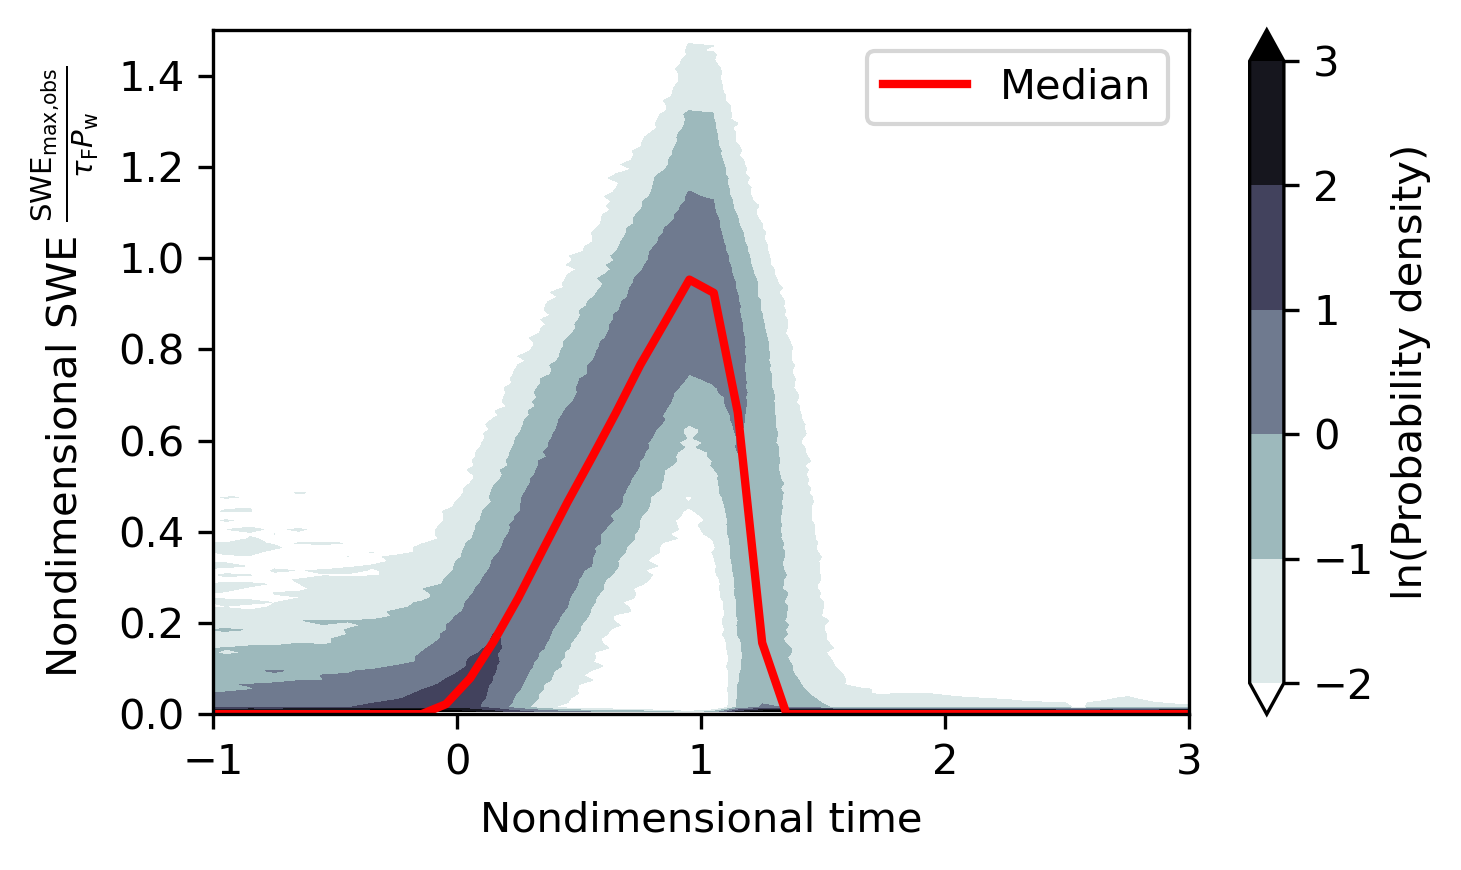

In [100]:
if choice == "Climatology":
    fig, ax1 = plt.subplots(figsize=(5,3),dpi=300)
    
    [tt,bb] = np.meshgrid(timeBinCenters,pdfBinCenters)
    c = plt.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-2,4,1),cmap='bone_r')
    plt.colorbar(c,label='ln(Probability density)')
    ax1.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
    ax1.set_xlim([-1,3])
    ax1.set_ylim([0,1.5])
    ax1.legend()
    ax1.set_ylabel(r'Nondimensional SWE $\left(\frac{\text{SWE}}{\tau_\text{F}P_\text{w}}\right)$')
    ax1.set_xlabel(r'Nondimensional time $\left(\frac{t-(t_\text{max}-\tau_\text{F})}{\tau_\text{F}}\right)$')
elif choice == "Water year":
    fig, ax1 = plt.subplots(figsize=(5,3),dpi=300)
    
    [tt,bb] = np.meshgrid(timeBinCenters,pdfBinCenters)
    c = plt.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-2,4,1),cmap='bone_r')
    plt.colorbar(c,label='ln(Probability density)')
    ax1.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
    ax1.set_xlim([-1,3])
    ax1.set_ylim([0,1.5])
    ax1.legend()
    ax1.set_ylabel(r'Nondimensional SWE $\frac{\text{SWE}_\text{max,obs}}{\tau_\text{F}P_\text{w}}$')
    ax1.set_xlabel('Nondimensional time')

plt.tight_layout()

## Save figure
saveBool = 0
if saveBool:
    plt.savefig(f'/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figure_universalSWECurve.pdf')

## Save data for final plot
saveData = 0
if saveData:
    ## This is the data that is going in the final figure. Save it here for plotting.
    pathToSave = '...../figureData'
    np.savez(pathToSave + f'/figureSWECurvesNonDim_{choice}.npz',
             Xmean=Xmean,
             Ymean=Ymean,
             tt=tt,
             bb=bb,
             allHist=allHist,
             )

## Dimensional data

In [101]:
allXDim = np.array(flatten(allTimes))
allYDim = np.array(flatten(allSWEs))

In [102]:
pdfBinEdges = np.linspace(0,2250,250)
pdfBinCenters = (pdfBinEdges[:-1] + pdfBinEdges[1:])/2

In [103]:
timeBinEdges = np.arange(0,366,1)
timeBinCenters = (timeBinEdges[:-1] + timeBinEdges[1:])/2

In [107]:
allHist = np.zeros((len(timeBinEdges)-1,len(pdfBinEdges)-1))
Xmean = []
Ymean = []
for i,tbs in tqdm(enumerate(timeBinEdges[:-1])):
    binStart = tbs
    binEnd = timeBinEdges[i+1]
    XinBin = allXDim[np.where(np.logical_and(allXDim>=binStart, allXDim<binEnd))]
    YinBin = allYDim[np.where(np.logical_and(allXDim>=binStart, allXDim<binEnd))]
    hist = np.histogram(YinBin,pdfBinEdges,density=True)[0]
    allHist[i,:]=hist

    Xmean = np.append(Xmean,np.mean(XinBin))
    Ymean = np.append(Ymean,np.mean(YinBin))

365it [00:08, 43.57it/s]


/tmp/ipykernel_142114/146938823.py:4: RuntimeWarning: divide by zero encountered in log
  c = plt.contourf(tt,bb,np.log(allHist.T),extend='both',cmap='bone')#,levels=np.arange(-9,-3))


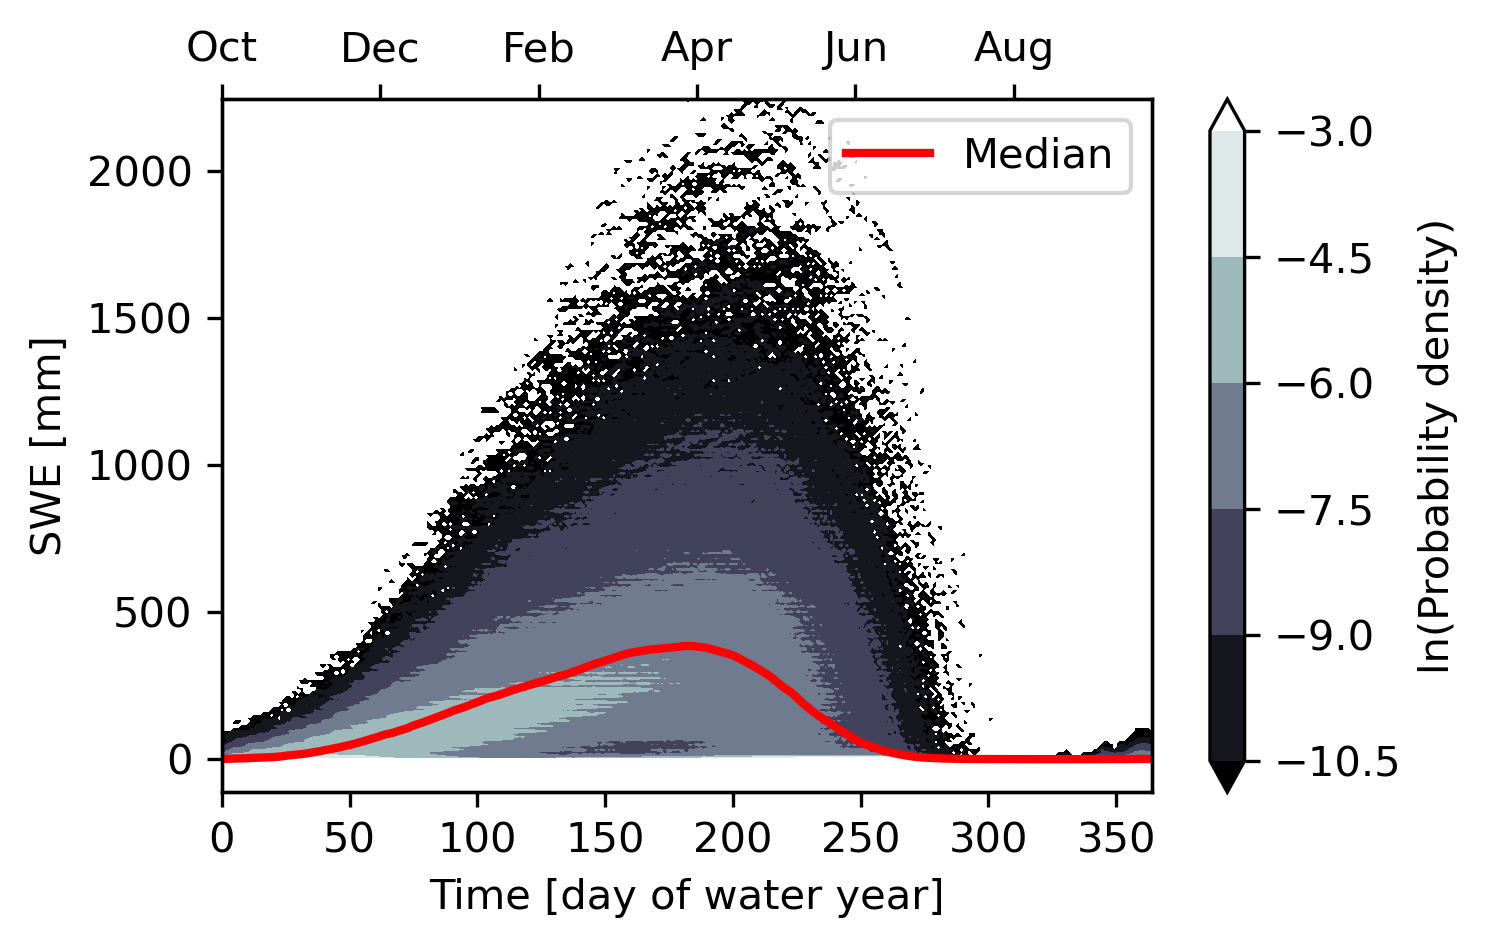

In [108]:
fig, ax1 = plt.subplots(figsize=(5,3),dpi=300)

[tt,bb] = np.meshgrid(timeBinCenters,pdfBinCenters)
c = plt.contourf(tt,bb,np.log(allHist.T),extend='both',cmap='bone')#,levels=np.arange(-9,-3))
plt.colorbar(c,label='ln(Probability density)')
ax1.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax1.legend()
ax1.set_ylabel(r'SWE [mm]')
ax1.set_xlabel('Time [day of water year]')
#ax1.set_ylim([0,1250])
ax1.set_xticks(np.arange(0,400,50))
ax1.set_xlim([0,364])

ax2 = ax1.twiny()
ax2.set_xlim([0,364])
ax2.set_xticks(np.arange(0,359,62))
ax2.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0);

## Save data for final plot
saveData = 0
if saveData:
    ## This is the data that is going in the final figure. Save it here for plotting.
    pathToSave = '...../figureData'
    np.savez(pathToSave + f'/figureSWECurvesDim_{choice}.npz',
             Xmean=Xmean,
             Ymean=Ymean,
             tt=tt,
             bb=bb,
             allHist=allHist,
             )

## Combine the dimensional and nondimensional data into a single plot

365it [00:08, 45.25it/s]
/tmp/ipykernel_142114/2042472993.py:33: RuntimeWarning: divide by zero encountered in log
  c = ax0.contourf(tt,bb,np.log(allHist.T),extend='both',cmap='bone_r',levels=np.arange(-9,-3))
62it [00:01, 59.93it/s]
/tmp/ipykernel_142114/2042472993.py:78: RuntimeWarning: divide by zero encountered in log
  c = ax1.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-2,4,1),cmap='bone_r')


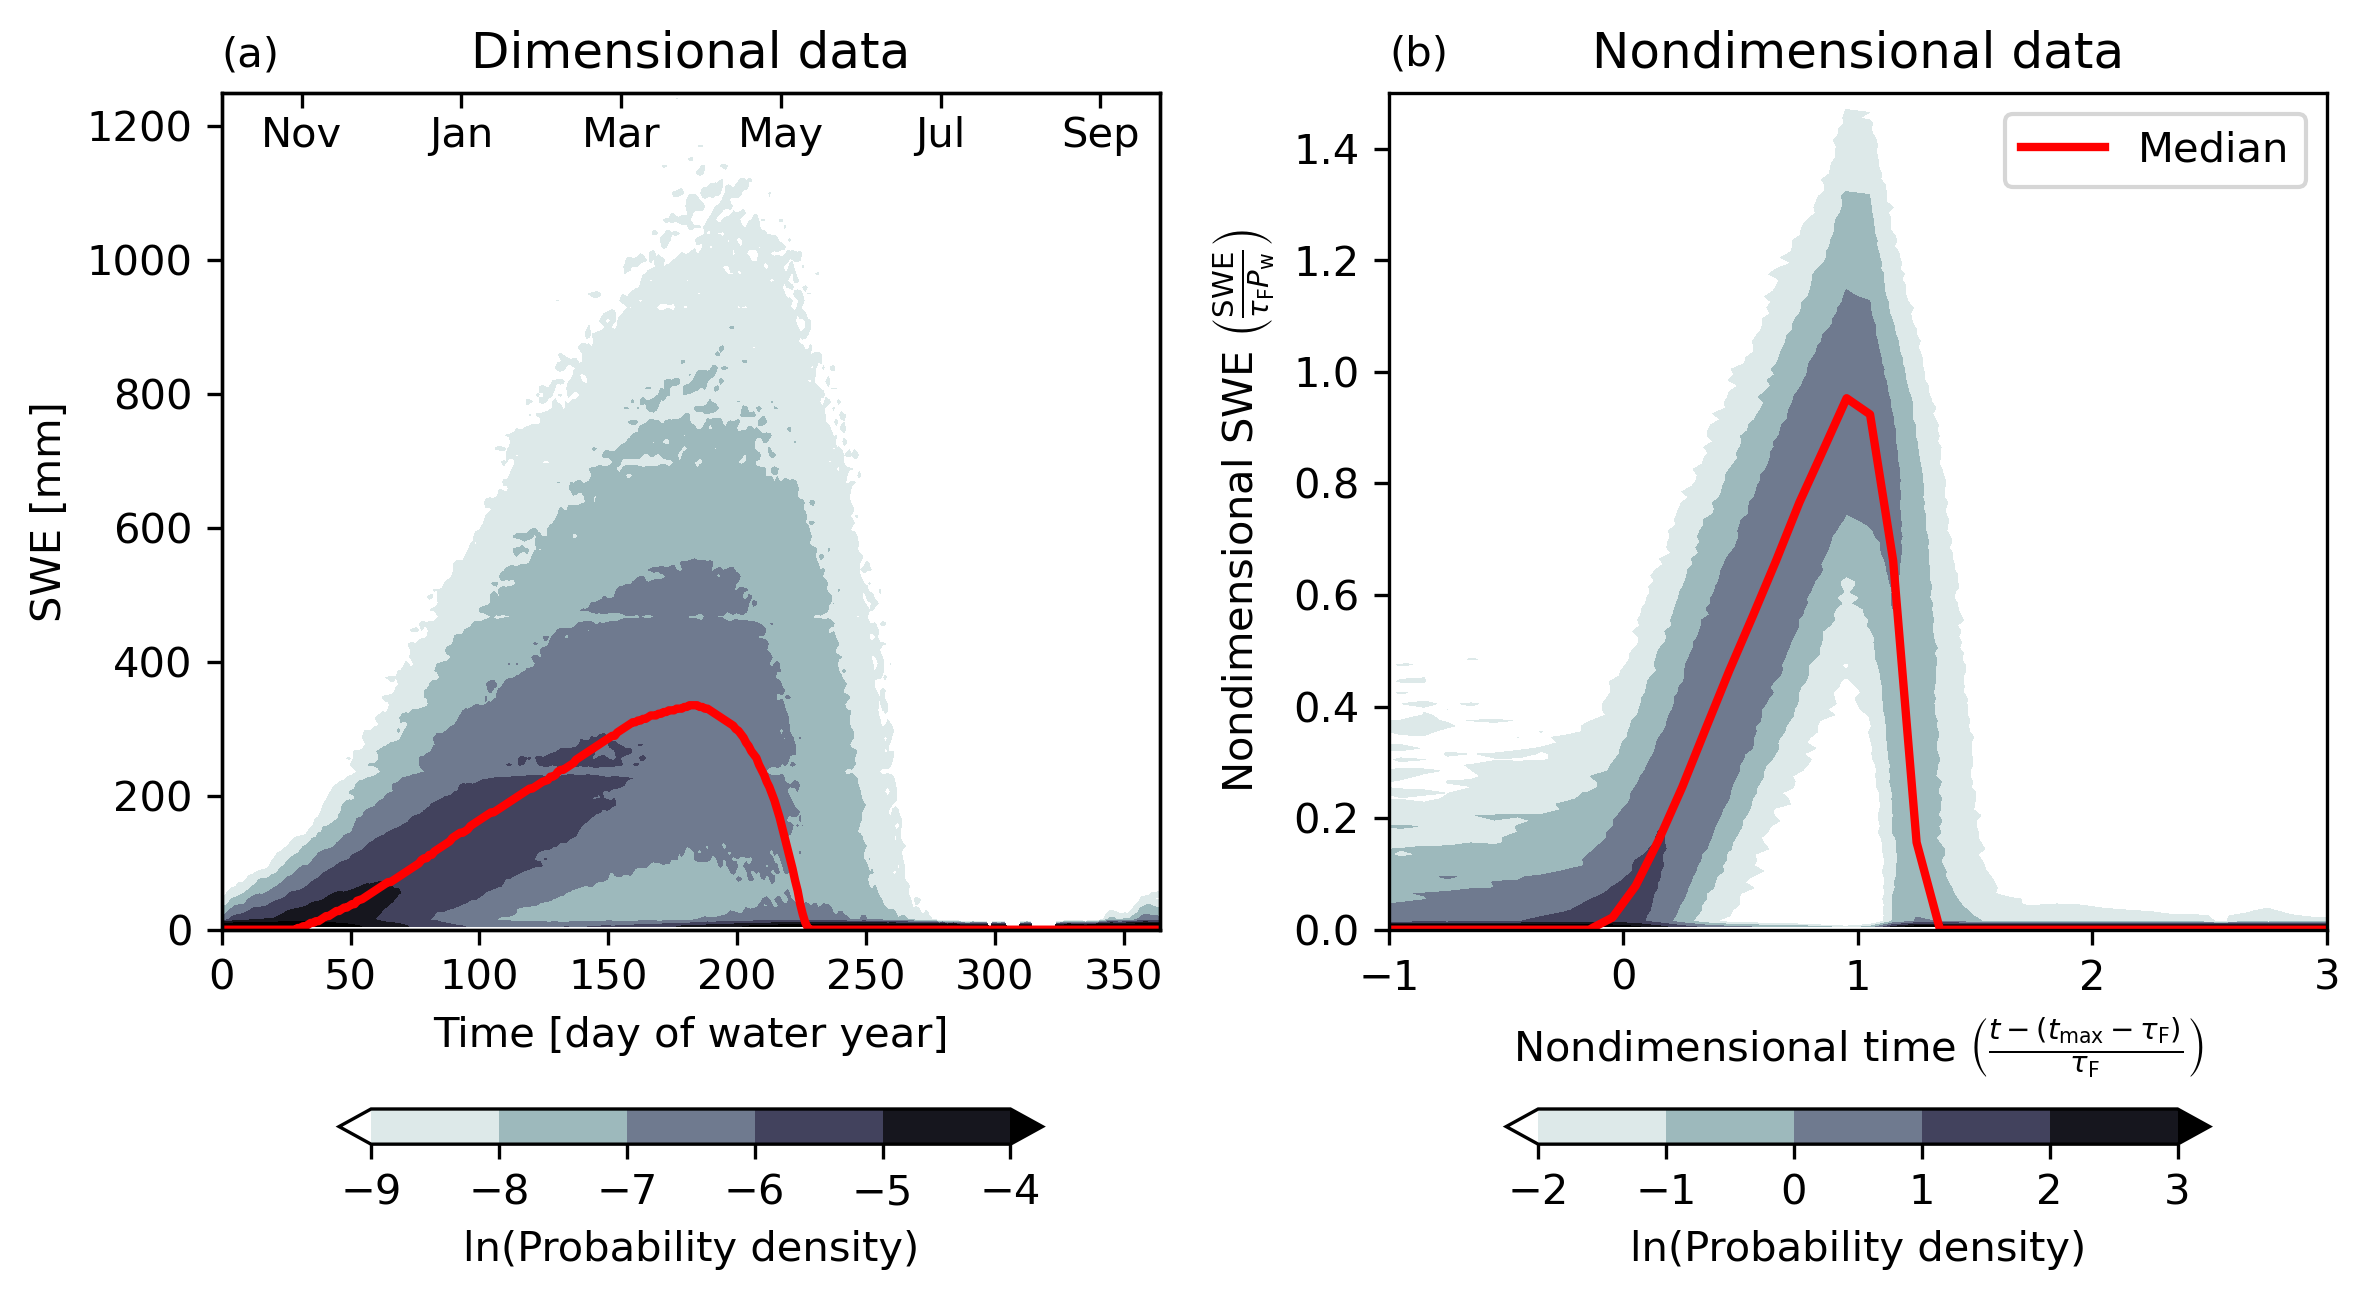

In [95]:
fig, ax = plt.subplots(1,2,figsize=(8,4.5),dpi=300)
ax0 = ax[0]
ax1 = ax[1]

###########################################
# Plot dimensional climatological data #
###########################################

allXDim = np.array(flatten(allTimes))
allYDim = np.array(flatten(allSWEs))

pdfBinEdges = np.linspace(0,2000,200)
pdfBinCenters = (pdfBinEdges[:-1] + pdfBinEdges[1:])/2

timeBinEdges = np.arange(0,366,1)
timeBinCenters = (timeBinEdges[:-1] + timeBinEdges[1:])/2

allHist = np.zeros((len(timeBinEdges)-1,len(pdfBinEdges)-1))
Xmean = []
Ymean = []
for i,tbs in tqdm(enumerate(timeBinEdges[:-1])):
    binStart = tbs
    binEnd = timeBinEdges[i+1]
    XinBin = allXDim[np.where(np.logical_and(allXDim>=binStart, allXDim<=binEnd))]
    YinBin = allYDim[np.where(np.logical_and(allXDim>=binStart, allXDim<=binEnd))]
    hist = np.histogram(YinBin,pdfBinEdges,density=True)[0]
    allHist[i,:]=hist

    Xmean = np.append(Xmean,np.mean(XinBin))
    Ymean = np.append(Ymean,np.median(YinBin))

[tt,bb] = np.meshgrid(timeBinCenters,pdfBinCenters)
c = ax0.contourf(tt,bb,np.log(allHist.T),extend='both',cmap='bone_r',levels=np.arange(-9,-3))
plt.colorbar(c,ax=ax0,label='ln(Probability density)',orientation='horizontal',shrink=.75)
ax0.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax0.set_ylabel(r'SWE [mm]')
ax0.set_xlabel('Time [day of water year]')
ax0.set_ylim([0,1250])
ax0.set_xticks(np.arange(0,400,50))
ax0.set_xlim([0,364])

ax2 = ax0.twiny()
ax2.set_xlim([0,364])
ax2.set_xticks(np.arange(0,359,62)+31)
ax2.set_xticklabels(['Nov','Jan','Mar','May','Jul','Sep'],rotation=0);
ax2.tick_params(axis="x",direction="in",pad=-15)
ax0.set_title('Dimensional data')
ax0.text(0,1290,'(a)');

###########################################
# Plot nondimensional climatological data #
###########################################

allX = np.array(flatten(allNonDimTimes))
allY = np.array(flatten(allNonDimSWEs))

pdfBinEdges = np.arange(0,2.3,.01)
pdfBinCenters = (pdfBinEdges[:-1] + pdfBinEdges[1:])/2

timeBinEdges = np.append(np.append(-100,np.arange(-3,3.1,.1)),100)
timeBinCenters = (timeBinEdges[:-1] + timeBinEdges[1:])/2

allHist = np.zeros((len(timeBinEdges)-1,len(pdfBinEdges)-1))
Xmean = []
Ymean = []
for i,tbs in tqdm(enumerate(timeBinEdges[:-1])):
    binStart = tbs
    binEnd = timeBinEdges[i+1]
    XinBin = allX[np.where(np.logical_and(allX>=binStart, allX<=binEnd))]
    YinBin = allY[np.where(np.logical_and(allX>=binStart, allX<=binEnd))]
    hist = np.histogram(YinBin,pdfBinEdges,density=True)[0]
    allHist[i,:]=hist

    Xmean = np.append(Xmean,np.mean(XinBin))
    Ymean = np.append(Ymean,np.median(YinBin))

[tt,bb] = np.meshgrid(timeBinCenters,pdfBinCenters)
c = ax1.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-2,4,1),cmap='bone_r')
plt.colorbar(c,ax=ax1,label='ln(Probability density)',orientation='horizontal',shrink=.75)
ax1.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax1.set_xlim([-1,3])
ax1.set_ylim([0,1.5])
ax1.legend()
ax1.set_ylabel(r'Nondimensional SWE $\left(\frac{\text{SWE}}{\tau_\text{F}P_\text{w}}\right)$')
ax1.set_xlabel(r'Nondimensional time $\left(\frac{t-(t_\text{max}-\tau_\text{F})}{\tau_\text{F}}\right)$')
ax1.set_title('Nondimensional data')
ax1.text(-1,1.55,'(b)');

plt.tight_layout()

In [86]:
ax1

<Axes: xlabel='Time [day of water year]', ylabel='SWE [mm]'>